# Microcircuit example

## Step 1: Import the package

Import the microcircuit python package and the default parameters:

In [2]:
import numpy as np

from microcircuit.model import Model
from microcircuit.parameter_definitions import Parameters

## Step 2: Configure the network and the simulation environment.

In [3]:
# Initialze the Parameter-class
P = Parameters()

Overwrite the default scaling factor to reduce the network size. The parameters `N_scaling` and `K_scaling` scale the total number of neurons and the total number of synapses, respectively.

In [4]:
scaling_factor = 0.2
P.N_scaling = scaling_factor
P.K_scaling = scaling_factor

Set the simulation time (in ms) and the path to the simulation data. Suppress printing the simulation progress to screen.

In [7]:
P.t_sim = 200
P.data_path = "data/"
P.print_time = False

## Step 3: Create the network

Instantiate the network. At this point, the primary parameters stored in `sim_dict`, `net_dict`, and `stim_dict` are attached to the network instance, and all secondary parameters are computed.

In [8]:
model = Model(P)

Data will be written to: data
  Directory has been created.

RNG seed: 55
Total number of virtual processes: 4
[INFO] [2026-09-07 15:19:04] Temporal resolution changed from 0.1 to 0.1 ms.


Here, the `UserWarning`s inform you that with the scaling factor of 0.2, two of the eight populations (L23E, L23I) receive too little (cortico-cortical) background inputs to fire in isolation. They may still generate spikes due to local inputs from other neurons within the network.

Create all neurons and devices, and connect the network.

In [9]:
model.create()
model.connect()

Creating neuronal populations.
Creating recording devices.
  Creating spike recorders.
Connecting neuronal populations recurrently.
[INFO] [2026-09-07 15:19:21] Preparing 15467 nodes for simulation.


## Step 4: Run the simulation

Simulate the network for `P.t_sim` ms.

In [10]:
model.simulate(P.t_presim)
model.simulate(P.t_sim)

Simulating 500.0 ms.
[INFO] [2026-09-07 15:19:27] Preparing 15467 nodes for simulation.
Simulating 200.0 ms.
[INFO] [2026-09-07 15:19:27] Number of local nodes: 15467
Simulation time (ms): 500
Number of OpenMP threads: 4
Not using MPI
[INFO] [2026-09-07 15:19:31] Simulation finished.
[INFO] [2026-09-07 15:19:31] Preparing 15467 nodes for simulation.
[INFO] [2026-09-07 15:19:31] Number of local nodes: 15467
Simulation time (ms): 200
Number of OpenMP threads: 4
Not using MPI
[INFO] [2026-09-07 15:19:33] Simulation finished.


## Step 5: Inspect the recorded spiking activity

The recorded spike data can be loaded from disk and visualized using the function `helpers.plot_raster()`. 

Interval to plot spikes: [500. 700.] ms
Interval to compute firing rates: [500. 700.] ms
Mean rates: [0.73  2.442 3.753 4.932 7.675 7.7   0.828 6.881] spikes/s
Standard deviation of rates: [2.009 3.56  4.539 5.363 6.836 6.616 2.201 6.115] spikes/s


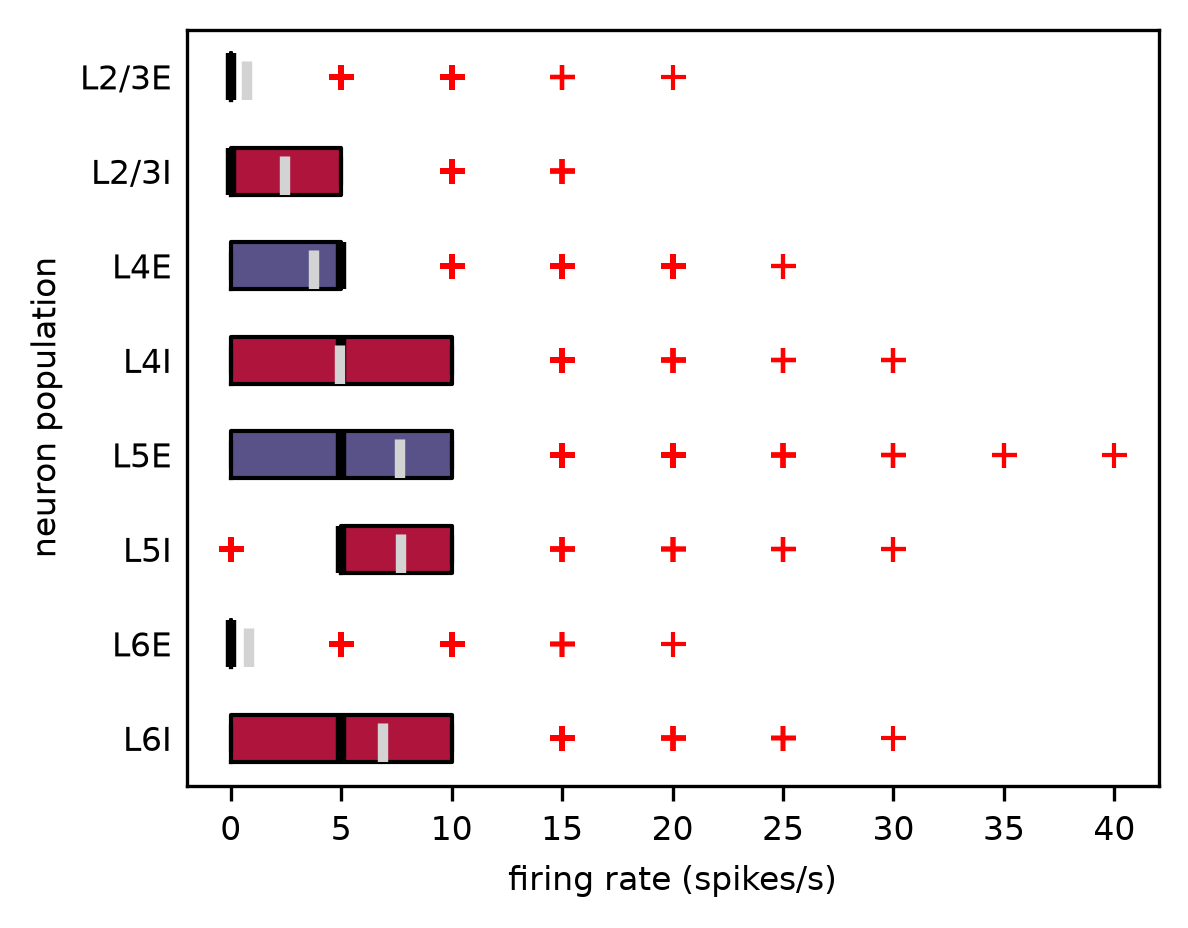

In [11]:
observation_interval = np.array([P.t_presim, P.t_presim + P.t_sim])
model.evaluate(observation_interval, observation_interval)

Visualization of the spiking activity in the network. Each dot represents a spike of the respective neuron at a given point in time.  Neuron ID's are sorted according to subpopulations (layers). Blue and red dots refer to spikes from excitatory and inhibitory neurons, respectively.